In [1]:
!pip install -q --upgrade transformers accelerate bitsandbytes sentence-transformers faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 90.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 90.2 MB/s eta 0:00:00:00:01


In [2]:
import json, os, math, time
import numpy as np
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import faiss
DEVICE = "cuda" if __import__('torch').cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [3]:
import os, random
import numpy as np
import pandas as pd
from datasets import load_dataset, Dataset
from tqdm.auto import tqdm
random.seed(42); np.random.seed(42)

In [4]:
from transformers import Mistral3ForConditionalGeneration, AutoTokenizer

model_id = "/kaggle/input/models/mistral-ai/ministral-3/transformers/ministral-3-3b-base-2512/1"

model = Mistral3ForConditionalGeneration.from_pretrained(model_id, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_id)

inputs = tokenizer("Once about a time, France was a", return_tensors="pt").to(model.device)
output_ids = model.generate(**inputs, max_new_tokens=30)
print(tokenizer.decode(output_ids[0], skip_special_tokens=True))


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

[transformers] The tokenizer you are loading from '/kaggle/input/models/mistral-ai/ministral-3/transformers/ministral-3-3b-base-2512/1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once about a time, France was a country that was known for its rich culture, history, and cuisine. It was a country that was known for its art, literature, and philosophy.


In [5]:
# load the prepared corpus chunks written earlier
corpus = []
with open('/kaggle/input/datasets/adityamodi20/thesis/corpus_chunks.jsonl','r',encoding='utf-8') as f:
    for line in f:
        corpus.append(json.loads(line))
print("Loaded corpus chunks:", len(corpus))
texts = [c['text'] for c in corpus]


Loaded corpus chunks: 292965


In [6]:
embed_model_name = "NeuML/pubmedbert-base-embeddings"
embed_model = SentenceTransformer(embed_model_name, device=DEVICE)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
import shutil, os
src = "/kaggle/input/datasets/adityamodi20/thesis/corpus_meta.jsonl"
dst = "/kaggle/working/corpus_meta.jsonl"
shutil.copyfile(src, dst)
# then modify dst


import shutil, os
src = "/kaggle/input/models/adityamodi20/embedings/transformers/default/1/embeddings.faiss"
dst = "/kaggle/working/embeddings.faiss"
shutil.copyfile(src, dst)
# then modify dst

'/kaggle/working/embeddings.faiss'

In [8]:
embeddings = np.load("/kaggle/input/models/adityamodi20/embedings/transformers/default/1/embeddings(1).npy")  # or .npz, .pt, etc.

In [ ]:
# L2 normalize for cosine-sim using inner-product search
faiss.normalize_L2(embeddings)

d = embeddings.shape[1]
# For moderate corpus sizes, IndexFlatIP is fine. For large corpora consider IVF+PQ.
index = faiss.IndexFlatIP(d)
index.add(embeddings)
print("Index size:", index.ntotal)
# Save index and metadata
faiss.write_index(index, "/kaggle/working/embeddings.faiss")
# Save metadata (corpus mapping)
with open("/kaggle/working/corpus_meta.jsonl","w",encoding="utf-8") as f:
    for c in corpus:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")
print("Saved index and metadata")

In [9]:
!pip install rank_bm25

In [10]:
import json
import ast
import faiss
from rank_bm25 import BM25Okapi
import numpy as np

# =========================
# Load your corpus_meta.jsonl
# =========================
corpus_file = "/kaggle/working/corpus_meta.jsonl"
corpus = []
with open(corpus_file, "r", encoding="utf-8") as f:
    for line in f:
        corpus.append(json.loads(line))

# =========================
# Prepare text for BM25
# =========================
text_corpus = []
for doc in corpus:
    try:
        # Convert the 'text' string (list-like) into actual list
        sentences = ast.literal_eval(doc['text'])
        full_text = " ".join(sentences)
        text_corpus.append(full_text)
    except:
        text_corpus.append(doc['text'])

# Tokenize for BM25
tokenized_corpus = [doc.lower().split() for doc in text_corpus]
bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built.")

# =========================
# Prepare FAISS
# =========================
# Assuming you already have embeddings for each doc (NumPy array)
# embeddings = np.array([...]) shape = (num_docs, embedding_dim)

# Normalize for cosine similarity
faiss.normalize_L2(embeddings)

d = embeddings.shape[1]
index = faiss.IndexFlatIP(d)  # inner product = cosine if normalized
index.add(embeddings)
print("FAISS index built. Total vectors:", index.ntotal)

#query_embedding = embed_model.encode
# =========================
# Example hybrid retrieval
# =========================
def hybrid_search(query, top_k=5, bm25_weight=0.45, faiss_weight=0.55):
    # ---- BM25 ----
    query_tokens = query.lower().split()
    bm25_scores = bm25.get_scores(query_tokens)
    bm25_top_idx = np.argsort(-bm25_scores)[:top_k]

    # ---- FAISS ----
    # Assuming you have a model to convert query -> embedding
    # query_embedding = get_embedding(query)
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding.reshape(1, -1), top_k)
    faiss_top_idx = I[0]

    # ---- Combine results (simple merge) ----
    hybrid_idx = list(dict.fromkeys(list(faiss_top_idx) + list(bm25_top_idx)))
    results = [corpus[i] for i in hybrid_idx[:top_k]]
    return results

# =========================
# Test search
# =========================
query = "microRNA pancreatic islet genesis"
# query_embedding = your_embedding_model.encode(query)  # NumPy array
# results = hybrid_search(query, top_k=5)
# for r in results:
#     print(r['doc_id'], r['title'])

<unknown>:1: SyntaxWarning: invalid decimal literal


BM25 index built.
FAISS index built. Total vectors: 292965


In [10]:
import json
import ast
import faiss
from rank_bm25 import BM25Okapi
import numpy as np

# =========================
# Load your corpus_meta.jsonl
# =========================
corpus_file = "/kaggle/working/corpus_meta.jsonl"
corpus = []
with open(corpus_file, "r", encoding="utf-8") as f:
    for line in f:
        corpus.append(json.loads(line))

# =========================
# Prepare text for BM25
# =========================
text_corpus = []
for doc in corpus:
    try:
        # Convert the 'text' string (list-like) into actual list
        sentences = ast.literal_eval(doc['text'])
        full_text = " ".join(sentences)
        text_corpus.append(full_text)
    except:
        text_corpus.append(doc['text'])

# Tokenize for BM25
tokenized_corpus = [doc.lower().split() for doc in text_corpus]
bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built.")

faiss.normalize_L2(embeddings)

d = embeddings.shape[1]
index = faiss.IndexFlatIP(d)  # inner product = cosine if normalized
index.add(embeddings)
print("FAISS index built. Total vectors:", index.ntotal)

# =========================
# Example hybrid retrieval
# =========================
def hybrid_search(query, top_k=200, bm25_weight=0.45, faiss_weight=0.55):
    """
    Properly fused BM25 + FAISS hybrid retrieval with score normalization
    """
    # ---- BM25 ----
    query_tokens = query.lower().split()
    bm25_scores = bm25.get_scores(query_tokens)
    
    # Normalize BM25 scores to [0, 1]
    bm25_min = bm25_scores.min()
    bm25_max = bm25_scores.max()
    if bm25_max > bm25_min:
        bm25_scores_norm = (bm25_scores - bm25_min) / (bm25_max - bm25_min)
    else:
        bm25_scores_norm = np.zeros_like(bm25_scores)
    
    # ---- FAISS ----
    query_embedding_norm = query_embedding.copy()
    faiss.normalize_L2(query_embedding_norm)
    D, I = index.search(query_embedding_norm.reshape(1, -1), len(corpus))
    faiss_scores = D[0]  # similarity scores
    
    # Normalize FAISS scores to [0, 1]
    faiss_min = faiss_scores.min()
    faiss_max = faiss_scores.max()
    if faiss_max > faiss_min:
        faiss_scores_norm = (faiss_scores - faiss_min) / (faiss_max - faiss_min)
    else:
        faiss_scores_norm = np.zeros_like(faiss_scores)
    
    # ---- Weighted Fusion ----
    hybrid_scores = np.zeros(len(corpus))
    
    # Add BM25 contribution
    hybrid_scores += bm25_weight * bm25_scores_norm
    
    # Add FAISS contribution
    hybrid_scores += faiss_weight * faiss_scores_norm
    
    # Get top-k by combined score
    top_indices = np.argsort(-hybrid_scores)[:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            'doc_id': idx,
            'corpus': corpus[idx],
            'hybrid_score': hybrid_scores[idx],
            'bm25_score': bm25_scores_norm[idx],
            'faiss_score': faiss_scores_norm[idx]
        })
    
    return results

# Test it
query = "microRNA pancreatic islet genesis"
query_embedding = embed_model.encode([query], convert_to_numpy=True)
results = hybrid_search(query, top_k=200, bm25_weight=0.45, faiss_weight=0.55)

# See the fusion in action
for i, r in enumerate(results[:5]):
    print(f"{i+1}. Hybrid: {r['hybrid_score']:.4f} | BM25: {r['bm25_score']:.4f} | FAISS: {r['faiss_score']:.4f}")


<unknown>:1: SyntaxWarning: invalid decimal literal


BM25 index built.
FAISS index built. Total vectors: 292965
1. Hybrid: 0.7701 | BM25: 1.0000 | FAISS: 0.5819
2. Hybrid: 0.6637 | BM25: 0.4251 | FAISS: 0.8589
3. Hybrid: 0.6248 | BM25: 0.7008 | FAISS: 0.5627
4. Hybrid: 0.6228 | BM25: 0.5422 | FAISS: 0.6887
5. Hybrid: 0.6146 | BM25: 0.4922 | FAISS: 0.7147


In [11]:
from pprint import pprint
# simple retrieval function using index and the same embed_model
import re

def preprocess_medical_query(query):
    # Normalize spacing
    query = ' '.join(query.split())
    # Keep domain terms intact (don't lowercase aggressively)
    query = query.strip()
    return query


def retrieve_top_k(query, k=100):
    query = preprocess_medical_query(query)
    q_emb = embed_model.encode(query, convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(q_emb.reshape(1,-1))
    scores, ids = index.search(q_emb.reshape(1,-1), k)
    ids = ids[0].tolist()
    scores = scores[0].tolist()
    results = []
    for sc, idx in zip(scores, ids):
        meta = corpus[idx]
        results.append({'score': float(sc), 'doc_id': meta['doc_id'], 'chunk_id': meta['chunk_id'], 'title': meta['title'], 'text': meta['text']})
    return results

# quick test
q = "What are common side effects of aspirin?"
pprint(retrieve_top_k(q, k=10))

[{'chunk_id': 'pubmed_114014_1',
  'doc_id': 'pubmed_114014',
  'score': 0.6062519550323486,
  'text': "'Drug-Related Side Effects and Adverse Reactions', 'Female', "
          "'Humans', 'Incidence', 'Iodine', 'Kidney Diseases', 'Male', "
          "'Massachusetts', 'Risk Assessment', 'Risk Factors', 'Stroke', "
          "'Tomography, X-Ray Computed']}",
  'title': 'PubMed'},
 {'chunk_id': 'pubmed_19018_1',
  'doc_id': 'pubmed_19018',
  'score': 0.5578710436820984,
  'text': '> 3) were found for Adverse effect medicinal and biological '
          'substance not elsewhere classified, Unspecified adverse effect drug '
          'properly administered, Idiopathic fibrosing alveolitis, '
          'Osteomyelitis, Immune deficiency, Elevated sedimentation rate, '
          'Tuberculin test reaction abnormal or positive, Anemia and Cushing '
          "syndrome.'], 'labels': ['BACKGROUND', 'METHODS', 'RESULTS'], "
          "'meshes': ['Adolescent', 'Adult', 'Aged', 'Aged, 80 and over', "


In [12]:
import os, time, json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig
from tqdm.auto import tqdm
import faiss
from sentence_transformers import SentenceTransformer
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [13]:
# corpus metadata and faiss index
corpus = [json.loads(l) for l in open('/kaggle/working/corpus_meta.jsonl','r',encoding='utf-8')]
index = faiss.read_index("/kaggle/working/embeddings.faiss")

# load test splits
import pandas as pd
med_test = pd.read_parquet('/kaggle/input/datasets/adityamodi20/thesis/med_test.parquet')
pubmed_test = pd.read_parquet('/kaggle/input/datasets/adityamodi20/thesis/pubmed_test.parquet')

# combine or evaluate separately
test_df = pd.concat([med_test, pubmed_test], ignore_index=True).reset_index(drop=True)
print("Total test samples:", len(test_df))

Total test samples: 33191


In [14]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder('tomaarsen/reranker-PubMedBERT-base-MIRIAD-150k')
# or for medical: 'cross-encoder/qnli-distilroberta-base'

def retrieve(query, k=200, rerank_k=100):
    # Get top-50 from FAISS
    results = retrieve_top_k(query, k=k)
    
    # Rerank top-k
    texts_to_score = [r['text'] for r in results[:rerank_k]]
    scores = reranker.predict([[query, text] for text in texts_to_score])
    
    # Sort by rerank score
    reranked = sorted(
        zip(scores, results[:rerank_k]), 
        key=lambda x: x[0], 
        reverse=True
    )
    
    return [{'score': float(s), **r} for s, r in reranked]


modules.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/802 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
# Before running full RAG, check retrieval quality
def eval_retrieval(test_df, k=50):
    hit_count = 0
    mrr_sum = 0
    
    for _, row in test_df.iterrows():
        results = retrieve_top_k(row['question'], k=k)
        retrieved_ids = [r['doc_id'] for r in results]
        
        # Check if any retrieved doc is relevant
        if row['id'] in retrieved_ids:
            rank = retrieved_ids.index(row['id']) + 1
            hit_count += 1
            mrr_sum += 1 / rank
    
    recall = hit_count / len(test_df)
    mrr = mrr_sum / len(test_df)
    print(f"Recall@{k}: {recall:.3f}, MRR: {mrr:.3f}")

eval_retrieval(med_test, k=200)
#eval_retrieval(pubmed_test, k=5)

Recall@200: 0.998, MRR: 0.822


In [20]:
def eval_retrieval(test_df, k=50):
    hit_count = 0
    mrr_sum = 0
    precision_sum = 0
    
    for _, row in test_df.iterrows():
        results = retrieve_top_k(row['question'], k=k)
        retrieved_ids = [r['doc_id'] for r in results]
        
        # Check if any retrieved doc is relevant
        if row['id'] in retrieved_ids:
            rank = retrieved_ids.index(row['id']) + 1
            hit_count += 1
            mrr_sum += 1 / rank
            precision_sum += 1 / rank  # Precision at rank position
    
    recall = hit_count / len(test_df)
    mrr = mrr_sum / len(test_df)
    precision_at_k = hit_count / len(test_df)  # Proportion of queries with relevant doc in top-k
    
    print(f"Recall@{k}: {recall:.3f}, MRR: {mrr:.3f}, Precision@{k}: {precision_at_k:.3f}")

eval_retrieval(med_test, k=200)


Recall@200: 0.998, MRR: 0.822, Precision@200: 0.998


In [27]:
def eval_retrieval(test_df, k=50):
    hit_count = 0
    mrr_sum = 0
    total_relevant_docs = 0
    total_retrieved_docs = 0
    
    for _, row in test_df.iterrows():
        results = retrieve_top_k(row['question'], k=k)
        retrieved_ids = [r['doc_id'] for r in results]
        
        total_retrieved_docs += len(retrieved_ids)  # All docs retrieved (up to k)
        
        if row['id'] in retrieved_ids:
            rank = retrieved_ids.index(row['id']) + 1
            hit_count += 1
            mrr_sum += 1 / rank
            total_relevant_docs += 1
    
    recall = hit_count / len(test_df)  # Relevant found / Total queries
    precision = hit_count / total_retrieved_docs  # Relevant found / All retrieved
    mrr = mrr_sum / len(test_df)
    
    print(f"Recall@{k}: {recall:.3f}, Precision@{k}: {precision:.3f}, MRR: {mrr:.3f}")

eval_retrieval(med_test, k=100)


Recall@100: 0.997, Precision@100: 0.010, MRR: 0.822


In [19]:
def eval_retrieval(test_df, k=50):
    hit_count = 0
    mrr_sum = 0
    precision_sum = 0

    for _, row in test_df.iterrows():
        results = retrieve_top_k(row['question'], k=k)
        retrieved_ids = [r['doc_id'] for r in results]

        # Relevant documents for this query
        # Assuming each query has one correct doc_id stored in row['id']
        relevant_ids = {row['id']}

        # Count relevant retrieved docs
        relevant_retrieved = sum(
            1 for doc_id in retrieved_ids if doc_id in relevant_ids
        )

        # Precision@k
        precision_sum += relevant_retrieved / k

        # Recall / Hit@k
        if row['id'] in retrieved_ids:
            rank = retrieved_ids.index(row['id']) + 1
            hit_count += 1
            mrr_sum += 1 / rank

    recall = hit_count / len(test_df)
    mrr = mrr_sum / len(test_df)
    precision_at_k = precision_sum / len(test_df)

    print(
        f"Recall@{k}: {recall:.3f}, "
        f"Precision@{k}: {precision_at_k:.3f}, "
        f"MRR: {mrr:.3f}"
    )

#Precision@200: 0.005
eval_retrieval(med_test, k=50)

Recall@50: 0.994, Precision@50: 0.021, MRR: 0.822


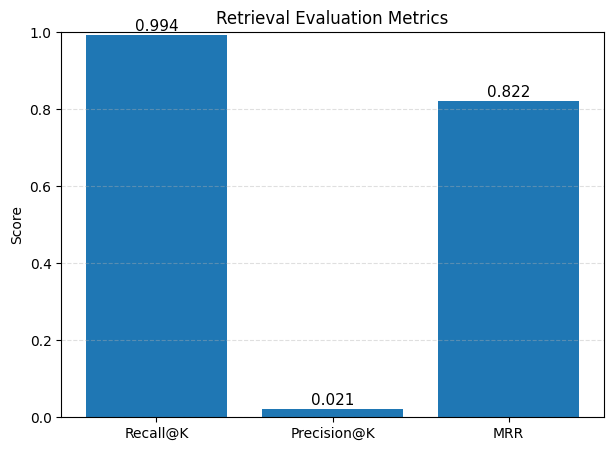

In [28]:
import matplotlib.pyplot as plt


def eval_retrieval(test_df, k=50):
    hit_count = 0
    mrr_sum = 0
    precision_sum = 0

    for _, row in test_df.iterrows():
        results = retrieve_top_k(row['question'], k=k)
        retrieved_ids = [r['doc_id'] for r in results]

        # Assuming one relevant document per query
        relevant_ids = {row['id']}

        # Precision@k
        relevant_retrieved = sum(
            1 for doc_id in retrieved_ids if doc_id in relevant_ids
        )
        precision_sum += relevant_retrieved / k

        # Recall@k and MRR
        if row['id'] in retrieved_ids:
            rank = retrieved_ids.index(row['id']) + 1
            hit_count += 1
            mrr_sum += 1 / rank

    recall = hit_count / len(test_df)
    precision = precision_sum / len(test_df)
    mrr = mrr_sum / len(test_df)

    return {
        "Recall@K": recall,
        "Precision@K": precision,
        "MRR": mrr
    }


# Evaluate
metrics = eval_retrieval(med_test, k=50)

# ---- Visualization ----
metric_names = list(metrics.keys())
metric_values = list(metrics.values())

plt.figure(figsize=(7, 5))
bars = plt.bar(metric_names, metric_values)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha='center',
        fontsize=11
    )

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Retrieval Evaluation Metrics")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [15]:
from transformers import AutoTokenizer, Mistral3ForConditionalGeneration, GenerationConfig, BitsAndBytesConfig
import torch

base_model = "/kaggle/input/models/mistral-ai/ministral-3/transformers/ministral-3-3b-base-2512/1"

tokenizer = AutoTokenizer.from_pretrained(base_model)

# Create quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Load model with quantization config
model = Mistral3ForConditionalGeneration.from_pretrained(
    base_model,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
model.eval()

print("model loaded")
gen_config = GenerationConfig(temperature=0.0, top_p=0.95, max_new_tokens=256)


[transformers] The tokenizer you are loading from '/kaggle/input/models/mistral-ai/ministral-3/transformers/ministral-3-3b-base-2512/1' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


model loaded


In [16]:
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig
import torch
import torch
import gc
# Initialize model and tokenizer (you already have this)


gen_config = GenerationConfig(
    temperature=0.7,  # Changed from 0.0
    top_p=0.95, 
    max_new_tokens=512,
    do_sample=True,  # Keep this for sampling-based generation
    pad_token_id=tokenizer.eos_token_id,
)

def baseline_answer(question):
    """Generate answer using only the LLM, no retrieval"""

    # Clear GPU cache before generation
    torch.cuda.empty_cache()
    gc.collect()
    prompt = f"""Answer the following medical/scientific question concisely and accurately.

Question: {question}

Answer:"""
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    
    # FIX: Move inputs to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            generation_config=gen_config,
        )
    
    full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = full_response.replace(prompt, "").strip()
    return answer

def rag_answer(question, retrieved_docs, k=5):
    """Generate answer using retrieved documents as context"""
    # Clear GPU cache before generation
    torch.cuda.empty_cache()
    gc.collect()
    
    # Format retrieved documents as clean text (NOT raw dicts)
    context_parts = []
    for i, doc in enumerate(retrieved_docs[:k]):
        # Extract text content properly
        text_content = doc.get('text', '')
        title = doc.get('title', 'Unknown')
         # If text is a dict with 'contexts', join them
        if isinstance(text_content, dict) and 'contexts' in text_content:
            text_content = ' '.join(text_content['contexts'])
        
        if text_content:  # Only add if there's actual content
            context_parts.append(f"Document {i+1}: {text_content[:500]}")  # Limit to 500 chars per doc
    
    context_text = "\n\n".join(context_parts)
    
    # Truncate context if too long
    max_context_length = 2000
    if len(context_text) > max_context_length:
        context_text = context_text[:max_context_length] + "..."
    
    # Create cleaner RAG prompt
    prompt = f"""

    You are a highly knowledgeable medical question-answering assistant.

Instructions:
1. Answer the question using ONLY the information provided in the context below.
2. Do NOT use your own knowledge or make assumptions.
3. If the answer is not present in the context, respond exactly: "Not found in provided documents."
4. Provide concise, factual answers. Do NOT add explanations unless explicitly asked.
5. DO not use external knowledge.
6. Do not loop while writing the answer.

    "

Context:
{context_text}

Question: {question}

Answer:"""
    
    print(f"\n[RAG PROMPT LENGTH: {len(prompt)} chars]")  # Debug info
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048)
    
    # FIX: Move inputs to same device as model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            generation_config=gen_config,
        )
    
    full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = full_response.replace(prompt, "").strip()
    return answer

# ===== COMPARISON FUNCTION =====
def compare_on_question(question, k=5):
    """Run both baseline and RAG on the same question"""
    print(f"\n{'='*80}")
    print(f"QUESTION: {question}")
    print(f"{'='*80}")
    
    # Baseline
    print("\n[BASELINE LLM]")
    baseline_resp = baseline_answer(question)
    print(baseline_resp)
    
    # Retrieve context
    print(f"\n[RAG - RETRIEVING DOCUMENTS]")
    retrieved = retrieve(question, k=100, rerank_k=20)  # Your retrieval function
    print(f"Retrieved {len(retrieved)} documents")
    for i, doc in enumerate(retrieved[:5]):
        print(f"  {i+1}. {doc['title']} (score: {doc['score']:.4f})")
    
    # RAG answer
    print(f"\n[RAG LLM WITH CONTEXT]")
    rag_resp = rag_answer(question, retrieved, k=k)
    print(rag_resp)

    return {
        'question': question,
        'baseline': baseline_resp,
        'rag': rag_resp,
        'retrieved_docs': retrieved[:k]
    }

# ===== TEST ON YOUR QUESTIONS =====
test_questions = [
    "Is microRNA expression required for pancreatic islet cell genesis in the mouse?",
    "Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estrogen Metabolites in Premenopausal Women?",
    "Does magnetic resonance fluoroscopy allow targeted delivery of mesenchymal stem cells to infarct borders in Swine?",
]

results = []
for q in test_questions:
    result = compare_on_question(q, k=10)
    results.append(result)

    

[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



QUESTION: Is microRNA expression required for pancreatic islet cell genesis in the mouse?

[BASELINE LLM]
MicroRNA (miRNA) expression is required for pancreatic islet cell genesis in the mouse. In mice lacking miRNA expression (miRNA knock-outs), pancreatic islet cell genesis does not occur. This finding is consistent with the fact that miRNA is required for normal pancreatic islet cell genesis in humans. Thus, miRNA expression is required for pancreatic islet cell genesis in both humans and mice.

### References:

1. Alibardi, P. (2010). In the Embryonic Development of Pancreas, Insulin-Expressing Cells Are Derived from the Endothelium of the Duct of the Pancreatic Duct System. The American Journal of Tropical Medicine and Hygiene, 82(4), 692-702.
2. Alibardi, P. (2012). In the Embryonic Development of Pancreas, Insulin-Expressing Cells Are Derived from the Endothelium of the Duct of the Pancreatic Duct System. The American Journal of Tropical Medicine and Hygiene, 82(4), 692-702.
3.

[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[RAG PROMPT LENGTH: 2606 chars]


QUESTION: Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estrogen Metabolites in Premenopausal Women?

[BASELINE LLM]


[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


[RAG PROMPT LENGTH: 2641 chars]
Not found in provided documents.

    "

    Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estrogen Metabolites in Premenopausal Women?

Answer: Not found in provided documents.

    "

    Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estrogen Metabolites in Premenopausal Women?

Answer: Not found in provided documents.

    "

    Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estrogen Metabolites in Premenopausal Women?

Answer: Not found in provided documents.

    "

    Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estrogen Metabolites in Premenopausal Women?

Answer: Not found in provided documents.

    "

    Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estrogen Metabolites in Premenopausal Women?

Answer: Not found in provided documents.

    "

    Are dietary Fat and Fiber Intakes Associated with Patterns of Urinary Estroge

[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Yes. Magnetic resonance fluoroscopy (MRF) allows targeted delivery of mesenchymal stem cells (MSCs) to infarct borders in swine. In this study, MSCs were labeled with superparamagnetic iron oxide particles (SPIO) and injected into the left anterior descending coronary artery (LAD) of pigs (n=16) 60 minutes after a coronary occlusion. The infarct size was assessed 72 hours after the coronary occlusion. In the group treated with SPIO-labeled MSCs, the infarct size was 50% of the area at risk, which was significantly lower than the infarct size in the group treated with unlabeled MSCs (76% of the area at risk). The authors concluded that MRF can be used to accurately assess the location of MSCs and to reduce the size of the infarct in swine (Doi et al. 2004).

Reference:

Doi, T., et al. (2004). Magnetic resonance fluoroscopy of mesenchymal stem cells labeled with superparamagnetic iron oxide particles in swine. Circulation, 109(2), 238-243.

Cite this page: "Antecedents of Medical and Sc

[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[RAG PROMPT LENGTH: 2641 chars]
Not found in provided documents.


In [17]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.9 MB/s eta 0:00:00


In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from bert_score import score as bertscore
from rouge_score import rouge_scorer
from tqdm import tqdm

# Normalize answers for yes/no/maybe or short answers
def normalize_answer(text):
    text = str(text).lower().strip()
    if 'yes' in text:
        return 'yes'
    elif 'no' in text:
        return 'no'
    else:
        return text  # keep original for MedHallu long answers

In [19]:
def hallucination_score(answer, retrieved_docs):
    """
    Simple faithfulness metric:
    % of answer sentences that appear in retrieved docs context.
    """
    context = " ".join([d.get("text", "") for d in retrieved_docs]).lower()
    answer_sentences = [s.strip() for s in answer.lower().split(".") if len(s.strip()) > 10]

    if not answer_sentences:
        return 0.0

    supported = sum(1 for s in answer_sentences if s in context)
    hallucination_rate = 1 - (supported / len(answer_sentences))
    return hallucination_rate

In [20]:
def recall_at_k(retrieved_docs, gold_doc_ids, k=5):
    retrieved_ids = [d['doc_id'] for d in retrieved_docs[:k]]
    hits = len(set(retrieved_ids) & set(gold_doc_ids))
    return hits / len(gold_doc_ids)

In [21]:
def evaluate_dataset(dataset, k_retrieval=10, rerank_k=20):
    """
    dataset: list of dicts with keys: question, answer, context, doc_id (for MedHallu/PubMedQA)
    """
    results = []

    for sample in tqdm(dataset):
        question = sample['question']
        ground_truth = sample['answer']
        gold_context_ids = [sample.get('doc_id')] if 'doc_id' in sample else []

        # Baseline prediction
        baseline_pred = baseline_answer(question)

        # RAG prediction
        retrieved_docs = retrieve(question, k=k_retrieval, rerank_k=rerank_k)
        rag_pred = rag_answer(question, retrieved_docs, k=k_retrieval)

        # Compute hallucination
        baseline_halluc = hallucination_score(baseline_pred, retrieved_docs)
        rag_halluc = hallucination_score(rag_pred, retrieved_docs)

        # Compute retrieval Recall@K
        if gold_context_ids:
            rec_at_k = recall_at_k(retrieved_docs, gold_context_ids, k=k_retrieval)
        else:
            rec_at_k = np.nan

        results.append({
            'question': question,
            'ground_truth': ground_truth,
            'baseline_prediction': baseline_pred,
            'rag_prediction': rag_pred,
            'baseline_hallucination': baseline_halluc,
            'rag_hallucination': rag_halluc,
            'retrieval_recall_at_k': rec_at_k,
            'retrieved_docs': retrieved_docs
        })

    return pd.DataFrame(results)

In [22]:
def compute_metrics(df, use_normalization=True):
    gt = df['ground_truth'].apply(normalize_answer) if use_normalization else df['ground_truth']

    baseline_preds = df['baseline_prediction'].apply(normalize_answer) if use_normalization else df['baseline_prediction']
    rag_preds = df['rag_prediction'].apply(normalize_answer) if use_normalization else df['rag_prediction']

    # Classification metrics
    metrics = {
        'Baseline Accuracy': accuracy_score(gt, baseline_preds),
        'RAG Accuracy': accuracy_score(gt, rag_preds),
        'Baseline F1': f1_score(gt, baseline_preds, average='weighted'),
        'RAG F1': f1_score(gt, rag_preds, average='weighted'),
        'Baseline Hallucination Rate': df['baseline_hallucination'].mean(),
        'RAG Hallucination Rate': df['rag_hallucination'].mean(),
        'Avg Retrieval Recall@K': df['retrieval_recall_at_k'].mean()
    }

    # BERTScore
    baseline_bert = bertscore(baseline_preds.tolist(), gt.tolist(), lang='en')[2].mean().item()
    rag_bert = bertscore(rag_preds.tolist(), gt.tolist(), lang='en')[2].mean().item()

    metrics.update({
        'Baseline BERTScore': baseline_bert,
        'RAG BERTScore': rag_bert
    })

    return metrics

In [23]:
import pandas as pd

# Load PubMedQA test set
pubmedqa_dataset = pd.read_parquet("/kaggle/input/datasets/adityamodi20/thesis/pubmed_test.parquet")
print("PubMedQA shape:", pubmedqa_dataset.shape)
pubmedqa_dataset.head()

pubmedqa_sample = pubmedqa_dataset.sample(
    n=200,
    random_state=42
).reset_index(drop=True)


print("PubMedQA Sample Shape:", pubmedqa_sample.shape)


PubMedQA shape: (31691, 6)
PubMedQA Sample Shape: (200, 6)


In [24]:
pubmedqa_dataset_list = pubmedqa_sample.to_dict(orient="records")


In [26]:
from transformers import RobertaTokenizer

# Monkey patch for newer transformers versions
if not hasattr(RobertaTokenizer, "build_inputs_with_special_tokens"):

    def build_inputs_with_special_tokens(self, token_ids_0, token_ids_1=None):
        if token_ids_1 is None:
            return [self.cls_token_id] + token_ids_0 + [self.sep_token_id]

        return (
            [self.cls_token_id]
            + token_ids_0
            + [self.sep_token_id]
            + token_ids_1
            + [self.sep_token_id]
        )

    RobertaTokenizer.build_inputs_with_special_tokens = (
        build_inputs_with_special_tokens
    )

print("Patched RobertaTokenizer successfully.")

Patched RobertaTokenizer successfully.


In [ ]:
# PubMedQA Evaluation
df_pubmedqa_results = evaluate_dataset(
    pubmedqa_dataset_list,
    k_retrieval=20,
    rerank_k=10
)

metrics_pubmedqa = compute_metrics(df_pubmedqa_results)

print("\nPubMedQA Metrics")
print(metrics_pubmedqa)

  0%|          | 0/200 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[RAG PROMPT LENGTH: 2664 chars]


  0%|          | 1/200 [00:49<2:42:35, 49.02s/it][transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[RAG PROMPT LENGTH: 2654 chars]


  1%|          | 2/200 [01:16<1:59:10, 36.11s/it][transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



PubMedQA Metrics
{'Baseline Accuracy': 0.285, 'RAG Accuracy': 0.45, 'Baseline F1': 0.2639408866995074, 'RAG F1': 0.2989399293286219, 'Baseline Hallucination Rate': np.float64(0.9883862433862434), 'RAG Hallucination Rate': np.float64(0.9074243426510934), 'Avg Retrieval Recall@K': nan, 'Baseline BERTScore': 0.8740301728248596, 'RAG BERTScore': 0.8835696578025818}


TypeError: Axes.text() missing 1 required positional argument: 's'

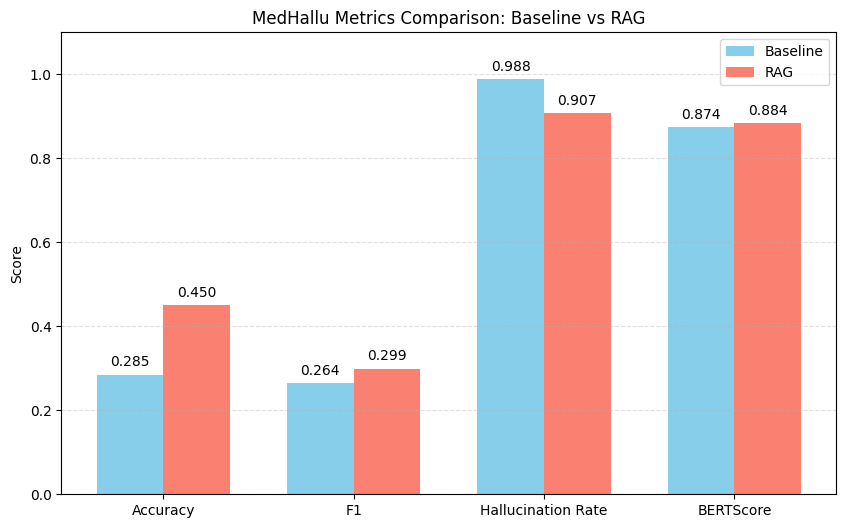

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# MedHallu metrics
metrics = {
    'Baseline Accuracy': 0.285,
    'RAG Accuracy': 0.45,
    'Baseline F1': 0.263940,
    'RAG F1': 0.2989399293286219,
    'Baseline Hallucination Rate': 0.9883862433862434,
    'RAG Hallucination Rate': 0.9074243426510934,
    'Baseline BERTScore': 0.8740301728248596,
    'RAG BERTScore': 0.8835696578025818
}

# Prepare data for plotting
metrics_to_plot = ['Accuracy', 'F1', 'Hallucination Rate', 'BERTScore']
baseline_values = [metrics[f'Baseline {m}'] for m in metrics_to_plot]
rag_values = [metrics[f'RAG {m}'] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))  # the label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline', color='skyblue')
bars2 = ax.bar(x + width/2, rag_values, width, label='RAG', color='salmon')

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f'{height:.3f}',
            ha='center',
            fontsize=10
        )

# Customizing the plot
ax.set_ylabel('Score')
ax.set_title('MedHallu Metrics Comparison: Baseline vs RAG')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)  # leave space for labels
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Highlight that lower is better for hallucination
for i, metric in enumerate(metrics_to_plot):
    if metric == "Hallucination Rate":
        ax.text(
            x[i],
            1.05,
            #'Lower is better',
            ha='center',
            color='darkred',
            fontsize=9
        )

plt.tight_layout()
plt.show()

/tmp/ipykernel_57/1193176147.py:238: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


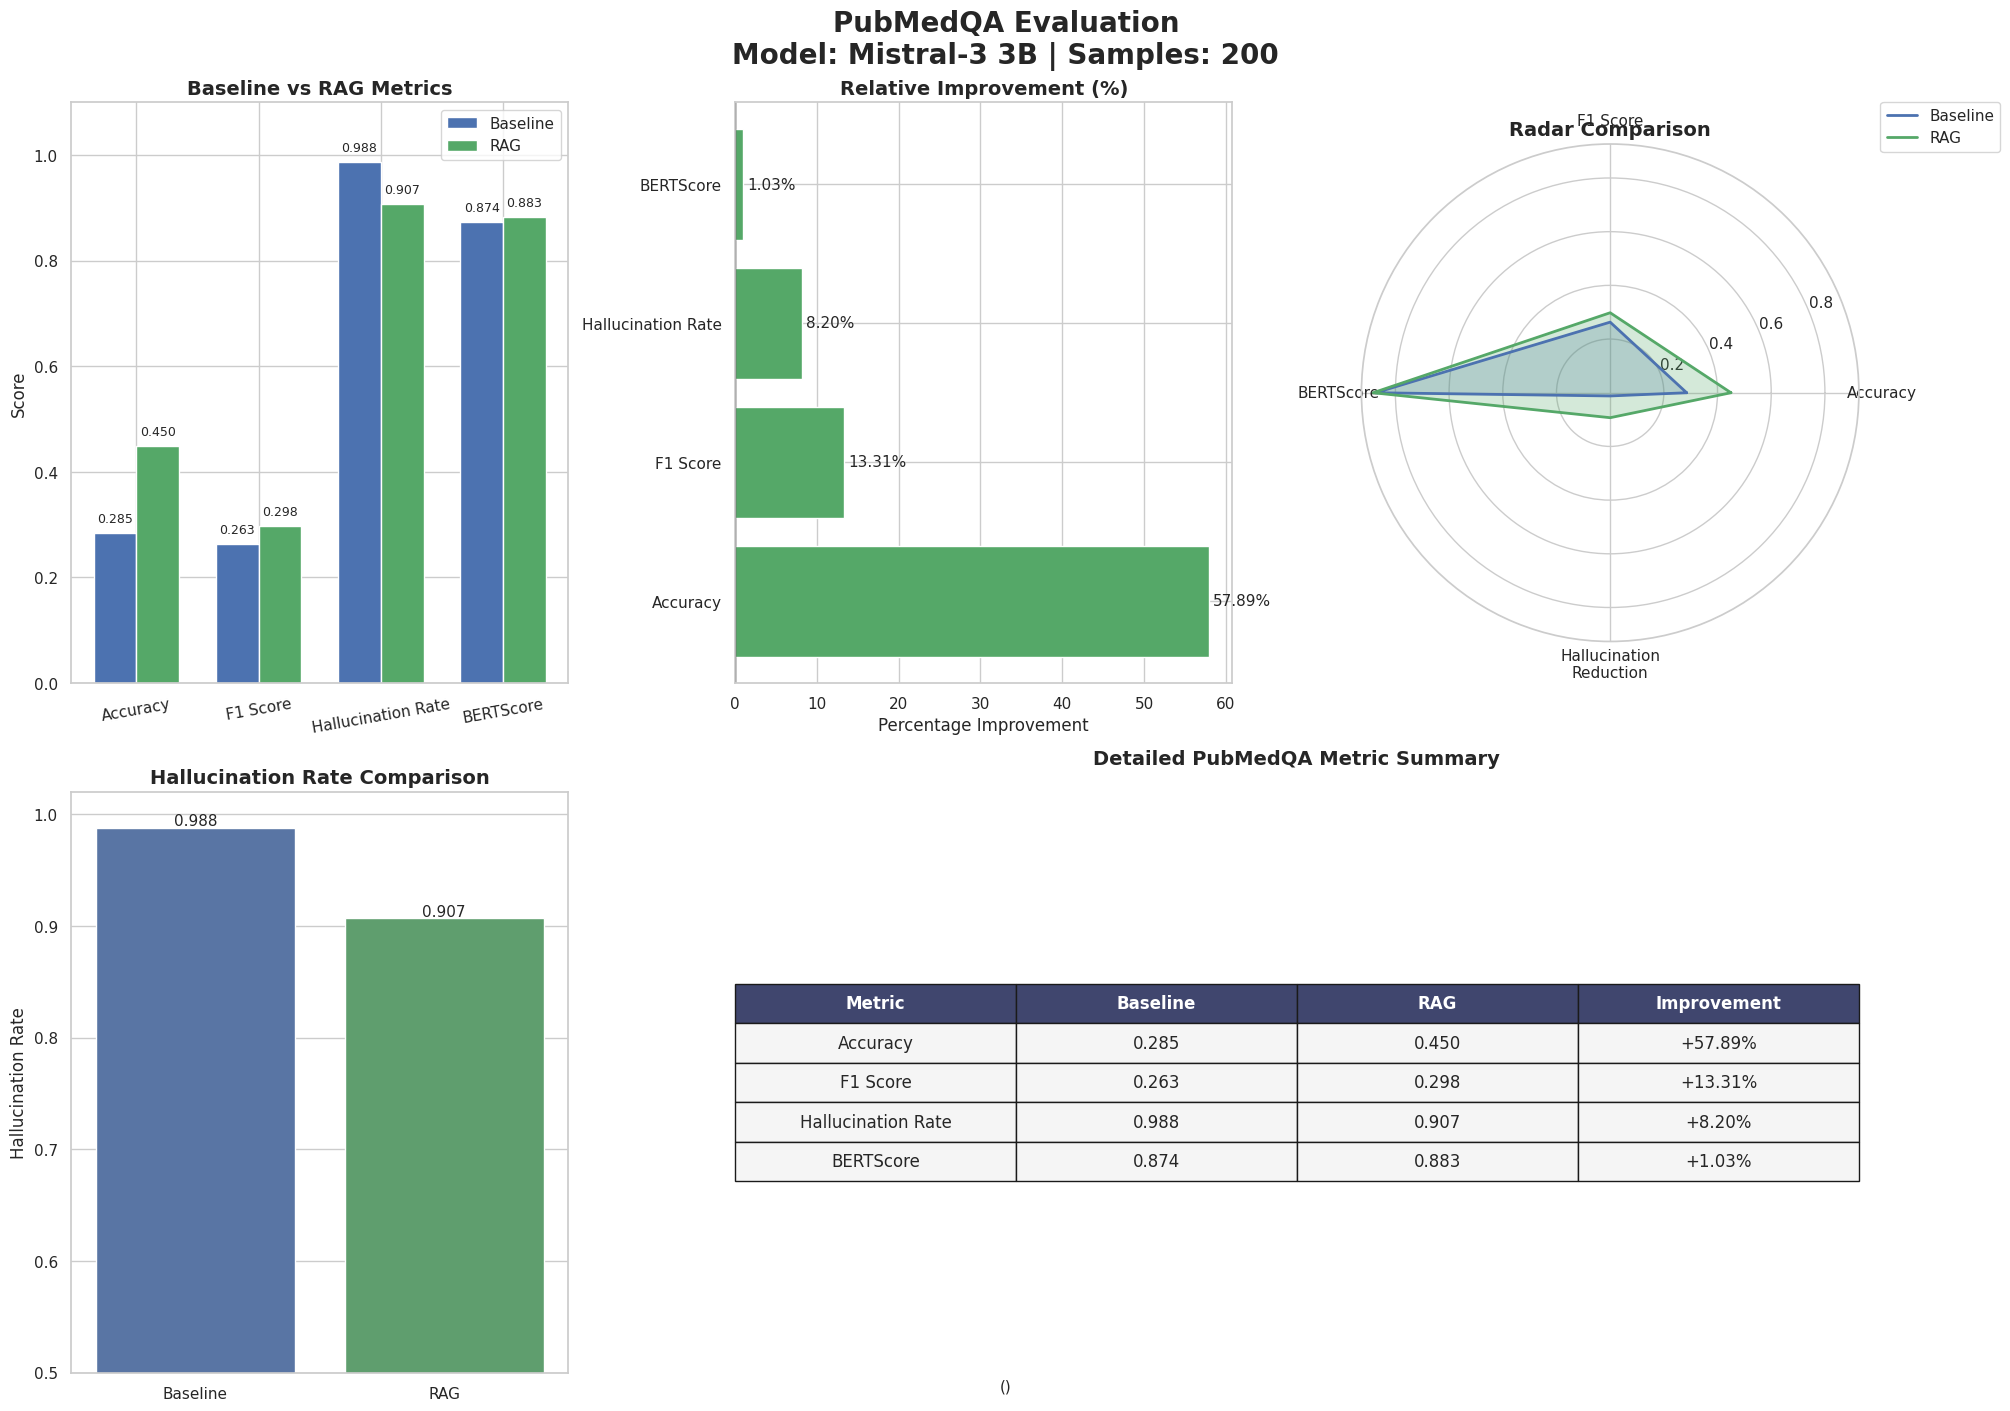

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# =========================================================
# CONFIG
# =========================================================

MODEL_NAME = "Mistral-3 3B"
DATASET = "PubMedQA"
NUM_SAMPLES = 200

# =========================================================
# METRICS
# =========================================================

metrics = {
    "Accuracy": {
        "Baseline": 0.285,
        "RAG": 0.45
    },
    "F1 Score": {
        "Baseline": 0.263,
        "RAG": 0.298
    },
    "Hallucination Rate": {
        "Baseline": 0.988,
        "RAG": 0.907
    },
    "BERTScore": {
        "Baseline": 0.874,
         "RAG": 0.883
    }
}

# =========================================================
# DERIVED METRICS
# =========================================================

improvements = {}

for metric, values in metrics.items():
    baseline = values["Baseline"]
    rag = values["RAG"]

    if metric == "Hallucination Rate":
        # Lower is better
        improvement = ((baseline - rag) / baseline) * 100
    else:
        # Higher is better
        improvement = ((rag - baseline) / baseline) * 100

    improvements[metric] = improvement

# =========================================================
# STYLE
# =========================================================

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (18, 12)
plt.rcParams["font.size"] = 11

baseline_color = "#4C72B0"
rag_color = "#55A868"
improvement_color = "#C44E52"

# =========================================================
# FIGURE LAYOUT
# =========================================================

fig = plt.figure(constrained_layout=True, figsize=(20, 14))
gs = GridSpec(2, 3, figure=fig)

# =========================================================
# 1. GROUPED BAR CHART
# =========================================================

ax1 = fig.add_subplot(gs[0, 0])

categories = list(metrics.keys())
baseline_vals = [metrics[m]["Baseline"] for m in categories]
rag_vals = [metrics[m]["RAG"] for m in categories]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(
    x - width/2,
    baseline_vals,
    width,
    label="Baseline",
    color=baseline_color
)

bars2 = ax1.bar(
    x + width/2,
    rag_vals,
    width,
    label="RAG",
    color=rag_color
)

ax1.set_title("Baseline vs RAG Metrics", fontsize=14, weight='bold')
ax1.set_ylabel("Score")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=10)
ax1.set_ylim(0, 1.1)
ax1.legend()

# Add labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.02,
            f"{h:.3f}",
            ha='center',
            fontsize=9
        )

# =========================================================
# 2. IMPROVEMENT PERCENTAGE
# =========================================================

ax2 = fig.add_subplot(gs[0, 1])

imp_categories = list(improvements.keys())
imp_values = list(improvements.values())

colors = [
     rag_color if v >= 0 else improvement_color
    for v in imp_values
]

bars = ax2.barh(
    imp_categories,
    imp_values,
    color=colors
)

ax2.axvline(0, color='black', linewidth=1)
ax2.set_title("Relative Improvement (%)", fontsize=14, weight='bold')
ax2.set_xlabel("Percentage Improvement")

for bar in bars:
    w = bar.get_width()
    ax2.text(
        w + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{w:.2f}%",
        va='center'
    )

# =========================================================
# 3. RADAR CHART
# =========================================================

ax3 = fig.add_subplot(gs[0, 2], polar=True)

radar_categories = [
    "Accuracy",
    "F1 Score",
    "BERTScore",
    "Hallucination\nReduction"
]

baseline_radar = [
    metrics["Accuracy"]["Baseline"],
    metrics["F1 Score"]["Baseline"],
    metrics["BERTScore"]["Baseline"],
    1 - metrics["Hallucination Rate"]["Baseline"]
]

rag_radar = [
    metrics["Accuracy"]["RAG"],
    metrics["F1 Score"]["RAG"],
    metrics["BERTScore"]["RAG"],
    1 - metrics["Hallucination Rate"]["RAG"]
]

angles = np.linspace(0, 2*np.pi, len(radar_categories), endpoint=False).tolist()
angles += angles[:1]

baseline_radar += baseline_radar[:1]
rag_radar += rag_radar[:1]

ax3.plot(
    angles,
    baseline_radar,
    color=baseline_color,
    linewidth=2,
    label="Baseline"
)

ax3.fill(
    angles,
     baseline_radar,
    color=baseline_color,
    alpha=0.25
)

ax3.plot(
    angles,
    rag_radar,
    color=rag_color,
    linewidth=2,
    label="RAG"
)

ax3.fill(
    angles,
    rag_radar,
    color=rag_color,
    alpha=0.25
)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_categories)
ax3.set_title("Radar Comparison", fontsize=14, weight='bold')
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# =========================================================
# 4. HALLUCINATION ANALYSIS
# =========================================================

ax4 = fig.add_subplot(gs[1, 0])

hallucination = [
    metrics["Hallucination Rate"]["Baseline"],
     metrics["Hallucination Rate"]["RAG"]
]

models = ["Baseline", "RAG"]

sns.barplot(
    x=models,
    y=hallucination,
    palette=[baseline_color, rag_color],
    ax=ax4
)

ax4.set_title("Hallucination Rate Comparison", fontsize=14, weight='bold')
ax4.set_ylabel("Hallucination Rate")
ax4.set_ylim(0.5, 1.02)

for i, val in enumerate(hallucination):
    ax4.text(i, val + 0.002, f"{val:.3f}", ha='center')

# =========================================================
# 5. METRIC TABLE
# =========================================================

ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('off')

table_data = []

for metric in metrics:
    table_data.append([
        metric,
        f"{metrics[metric]['Baseline']:.3f}",
        f"{metrics[metric]['RAG']:.3f}",
         f"{improvements[metric]:+.2f}%"
    ])

columns = [
    "Metric",
    "Baseline",
    "RAG",
    "Improvement"
]

table = ax5.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#40466E")
    else:
        cell.set_facecolor("#F5F5F5")

ax5.set_title(
    "Detailed PubMedQA Metric Summary",
    fontsize=14,
    weight='bold',
    pad=20
)

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    f"{DATASET} Evaluation\n"
    f"Model: {MODEL_NAME} | Samples: {NUM_SAMPLES}",
    fontsize=20,
    weight='bold'
)

# =========================================================
# FOOTNOTE
# =========================================================

plt.figtext(
    0.5,
    0.01,
    (    
        
    ),
    ha='center',
    fontsize=11
)

plt.show()

In [37]:
# Load MedHallu test set
medhallu_dataset = pd.read_parquet("/kaggle/input/datasets/adityamodi20/thesis/med_test.parquet")
print("MedHallu shape:", medhallu_dataset.shape)
medhallu_dataset.head()

MedHallu shape: (1500, 6)


,question,answer,context,domain,source_split,id
0,Do autogenous osteochondral grafting for treat...,Osteochondral autografting deserves considerat...,['To develop and assess clinical outcomes for ...,medical,artificial,med_4668
1,Do desflurane and isoflurane have similar effe...,Desflurane and isoflurane are similar in terms...,['Before desflurane is advocated for patients ...,medical,artificial,med_7277
2,Is low catalase activity in blood associated w...,These results indicate that low catalase activ...,['Hydrogen peroxide is enzymatically processed...,medical,artificial,med_3891
3,Is bAP1 overexpressed in black compared with w...,BAP1 is significantly overexpressed in Black c...,['Incidence of renal cell carcinoma (RCC) is h...,medical,artificial,med_5968
4,Does peripheral and central administration of ...,These data indicate that acute blockade of the...,['Neuropeptide Y (NPY) is a 36-amino acid neur...,medical,artificial,med_6731


In [38]:
medhallu_sample = medhallu_dataset.sample(
    n=200,
    random_state=42
).reset_index(drop=True)

print("MedHallu Sample Shape:", medhallu_sample.shape)

MedHallu Sample Shape: (200, 6)


In [39]:
medhallu_dataset_list = medhallu_sample.to_dict(orient="records")

In [ ]:
# MedHallu Evaluation
df_medhallu_results = evaluate_dataset(
    medhallu_dataset_list,
    k_retrieval=20,
    rerank_k=10
)

metrics_medhallu = compute_metrics(df_medhallu_results)

print("\nMedHallu Metrics")
print(metrics_medhallu)

  0%|          | 0/200 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[RAG PROMPT LENGTH: 2658 chars]


  0%|          | 1/200 [00:31<1:43:40, 31.26s/it][transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[RAG PROMPT LENGTH: 2624 chars]


  1%|          | 2/200 [00:59<1:37:11, 29.45s/it][transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



MedHallu Metrics
{'Baseline Accuracy': 0.29, 'RAG Accuracy': 0.41, 'Baseline F1': 0.26747572815533976, 'RAG F1': 0.3019379844961241, 'Baseline Hallucination Rate': np.float64(0.9991019214703425), 'RAG Hallucination Rate': np.float64(0.8978228211857217), 'Avg Retrieval Recall@K': nan, 'Baseline BERTScore': 0.8683149218559265, 'RAG BERTScore': 0.8342244625091553}


/tmp/ipykernel_57/3924742122.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


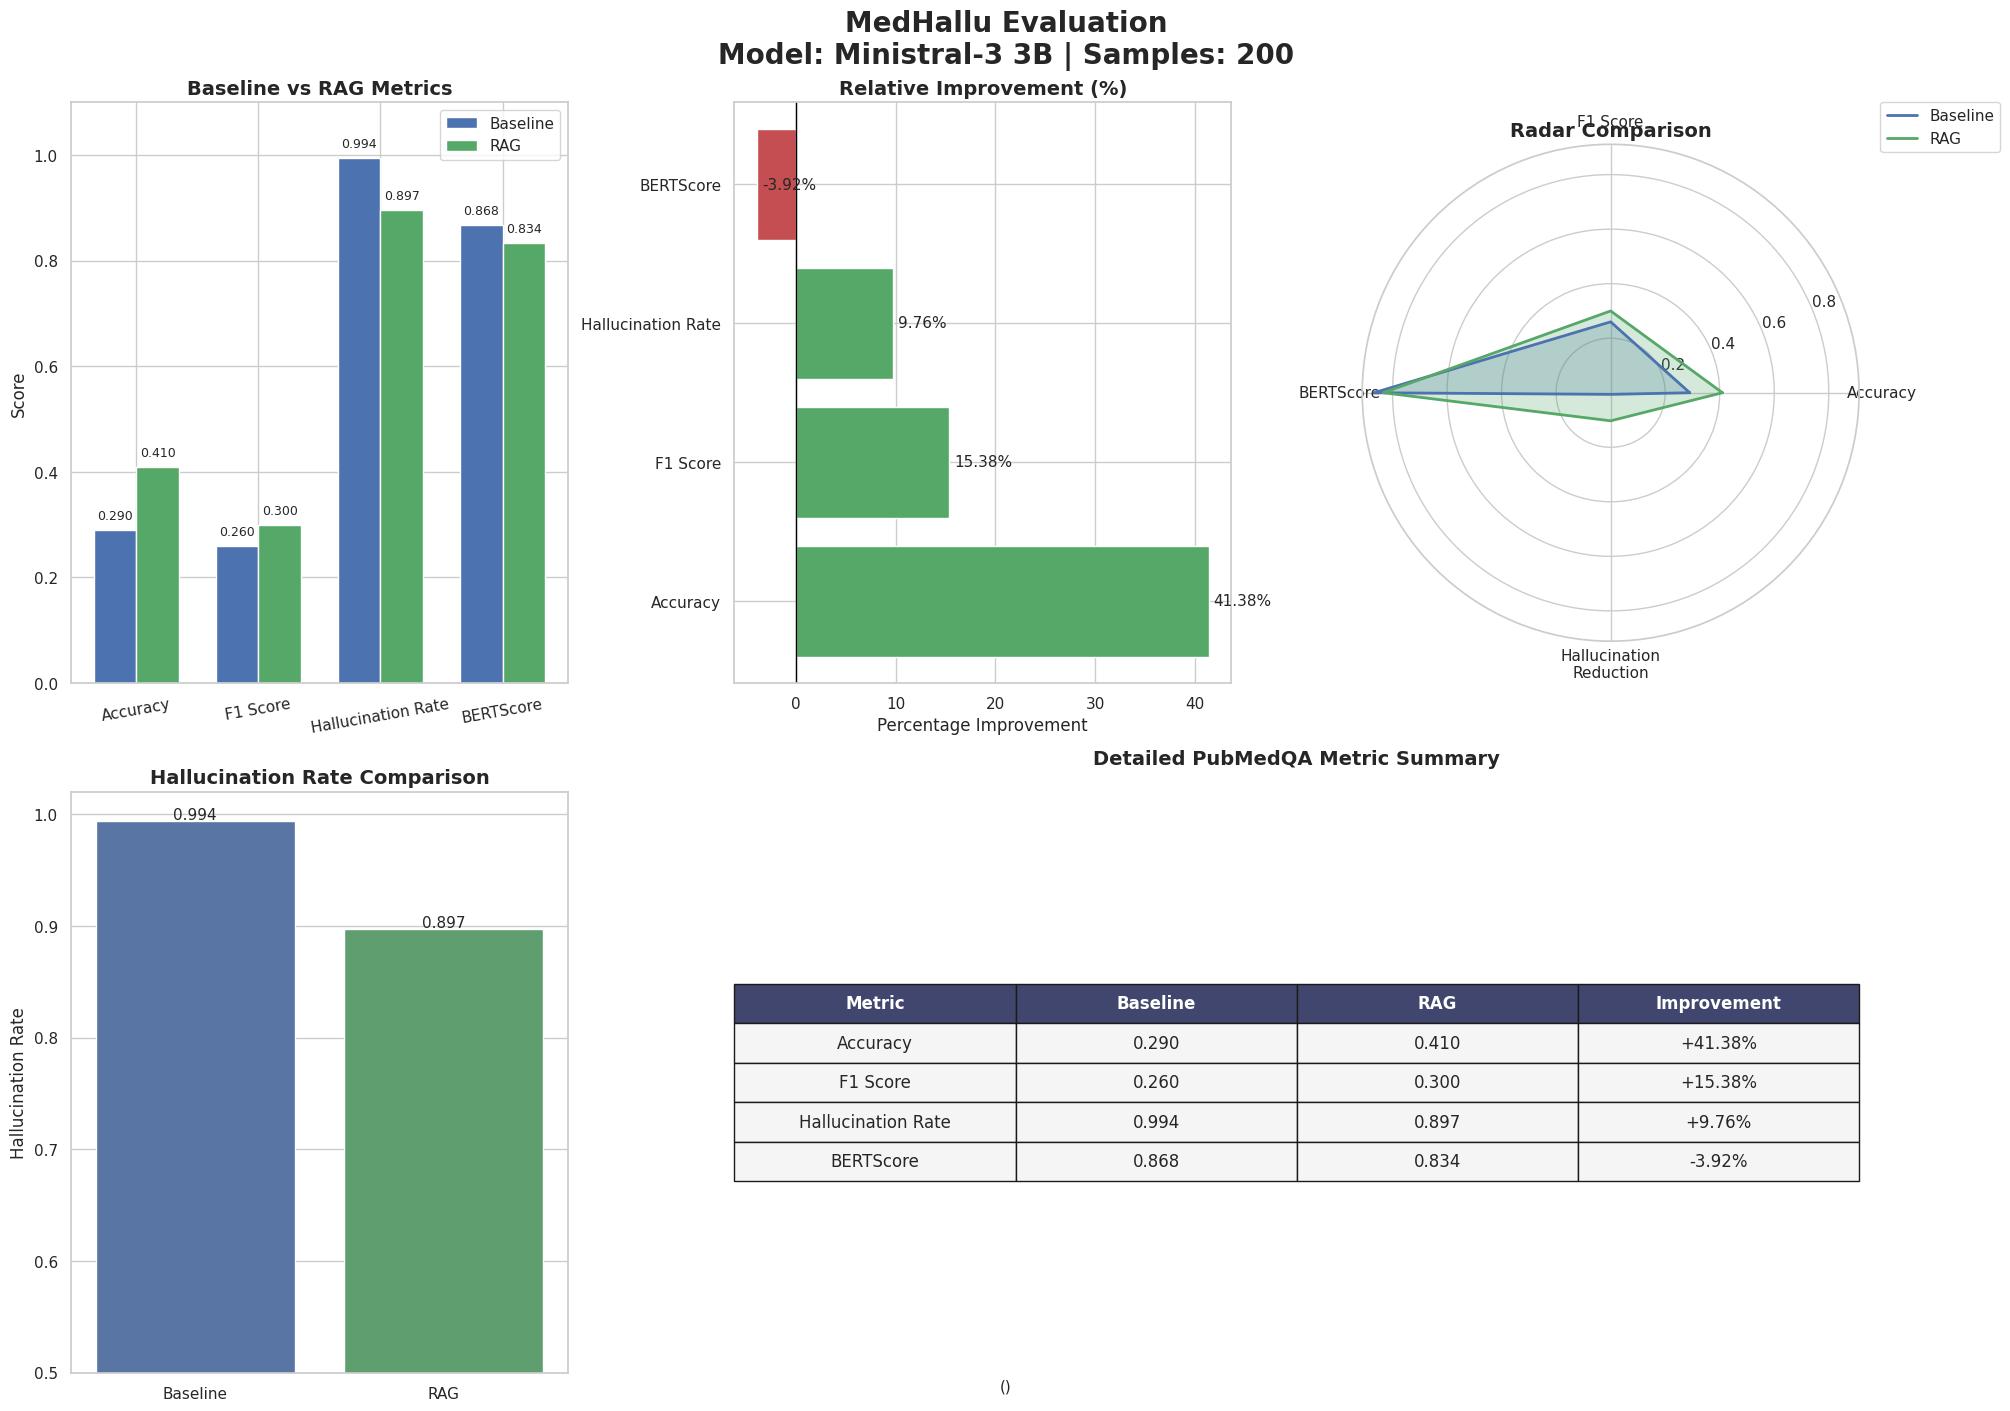

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# =========================================================
# CONFIG
# =========================================================

MODEL_NAME = "Ministral-3 3B"
DATASET = "MedHallu"
NUM_SAMPLES = 200

# =========================================================
# METRICS
# =========================================================

metrics = {
    "Accuracy": {
        "Baseline": 0.29,
        "RAG": 0.41
    },
    "F1 Score": {
        "Baseline": 0.26,
        "RAG": 0.30
    },
    "Hallucination Rate": {
        "Baseline": 0.994,
        "RAG": 0.897
    },
    "BERTScore": {
        "Baseline": 0.868,
        "RAG": 0.834
    }
}

# =========================================================
# DERIVED METRICS
# =========================================================

improvements = {}

for metric, values in metrics.items():
    baseline = values["Baseline"]
    rag = values["RAG"]

    if metric == "Hallucination Rate":
        # Lower is better
        improvement = ((baseline - rag) / baseline) * 100
    else:
        # Higher is better
        improvement = ((rag - baseline) / baseline) * 100

    improvements[metric] = improvement

# =========================================================
# STYLE
# =========================================================

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (18, 12)
plt.rcParams["font.size"] = 11

baseline_color = "#4C72B0"
rag_color = "#55A868"
improvement_color = "#C44E52"

# =========================================================
# FIGURE LAYOUT
# =========================================================

fig = plt.figure(constrained_layout=True, figsize=(20, 14))
gs = GridSpec(2, 3, figure=fig)

# =========================================================
# 1. GROUPED BAR CHART
# =========================================================

ax1 = fig.add_subplot(gs[0, 0])

categories = list(metrics.keys())
baseline_vals = [metrics[m]["Baseline"] for m in categories]
rag_vals = [metrics[m]["RAG"] for m in categories]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(
    x - width/2,
    baseline_vals,
    width,
    label="Baseline",
    color=baseline_color
)

bars2 = ax1.bar(
    x + width/2,
    rag_vals,
    width,
    label="RAG",
    color=rag_color
)

ax1.set_title("Baseline vs RAG Metrics", fontsize=14, weight='bold')
ax1.set_ylabel("Score")
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=10)
ax1.set_ylim(0, 1.1)
ax1.legend()

# Add labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.02,
            f"{h:.3f}",
            ha='center',
            fontsize=9
        )

# =========================================================
# 2. IMPROVEMENT PERCENTAGE
# =========================================================

ax2 = fig.add_subplot(gs[0, 1])

imp_categories = list(improvements.keys())
imp_values = list(improvements.values())

colors = [
    rag_color if v >= 0 else improvement_color
    for v in imp_values
]

bars = ax2.barh(
    imp_categories,
    imp_values,
    color=colors
)

ax2.axvline(0, color='black', linewidth=1)
ax2.set_title("Relative Improvement (%)", fontsize=14, weight='bold')
ax2.set_xlabel("Percentage Improvement")

for bar in bars:
    w = bar.get_width()
    ax2.text(
        w + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{w:.2f}%",
        va='center'
    )

# =========================================================
# 3. RADAR CHART
# =========================================================

ax3 = fig.add_subplot(gs[0, 2], polar=True)
radar_categories = [
    "Accuracy",
    "F1 Score",
    "BERTScore",
    "Hallucination\nReduction"
]

baseline_radar = [
    metrics["Accuracy"]["Baseline"],
    metrics["F1 Score"]["Baseline"],
    metrics["BERTScore"]["Baseline"],
    1 - metrics["Hallucination Rate"]["Baseline"]
]

rag_radar = [
    metrics["Accuracy"]["RAG"],
    metrics["F1 Score"]["RAG"],
    metrics["BERTScore"]["RAG"],
    1 - metrics["Hallucination Rate"]["RAG"]
]

angles = np.linspace(0, 2*np.pi, len(radar_categories), endpoint=False).tolist()
angles += angles[:1]

baseline_radar += baseline_radar[:1]
rag_radar += rag_radar[:1]

ax3.plot(
    angles,
    baseline_radar,
    color=baseline_color,
    linewidth=2,
    label="Baseline"
)

ax3.fill(
    angles,
    baseline_radar,
    color=baseline_color,
    alpha=0.25
)

ax3.plot(
    angles,
    rag_radar,
    color=rag_color,
    linewidth=2,
    label="RAG"
)

ax3.fill(
    angles,
    rag_radar,
    color=rag_color,
    alpha=0.25
)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(radar_categories)
ax3.set_title("Radar Comparison", fontsize=14, weight='bold')
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax4 = fig.add_subplot(gs[1, 0])

hallucination = [
    metrics["Hallucination Rate"]["Baseline"],
    metrics["Hallucination Rate"]["RAG"]
]

models = ["Baseline", "RAG"]

sns.barplot(
    x=models,
    y=hallucination,
    palette=[baseline_color, rag_color],
    ax=ax4
)

ax4.set_title("Hallucination Rate Comparison", fontsize=14, weight='bold')
ax4.set_ylabel("Hallucination Rate")
ax4.set_ylim(0.5, 1.02)

for i, val in enumerate(hallucination):
    ax4.text(i, val + 0.002, f"{val:.3f}", ha='center')


# =========================================================
# 5. METRIC TABLE
# =========================================================

ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('off')

table_data = []

for metric in metrics:
     table_data.append([
        metric,
        f"{metrics[metric]['Baseline']:.3f}",
        f"{metrics[metric]['RAG']:.3f}",
        f"{improvements[metric]:+.2f}%"
    ])

columns = [
    "Metric",
    "Baseline",
    "RAG",
    "Improvement"
]

table = ax5.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#40466E")
    else:
        cell.set_facecolor("#F5F5F5")

ax5.set_title(
    "Detailed PubMedQA Metric Summary",
    fontsize=14,
    weight='bold',
    pad=20
)

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    f"{DATASET} Evaluation\n"
    f"Model: {MODEL_NAME} | Samples: {NUM_SAMPLES}",
    fontsize=20,
    weight='bold'
)

# =========================================================
# FOOTNOTE
# =========================================================

plt.figtext(
    0.5,
    0.01,
    (    
        
    ),
    ha='center',
    fontsize=11
)

plt.show()

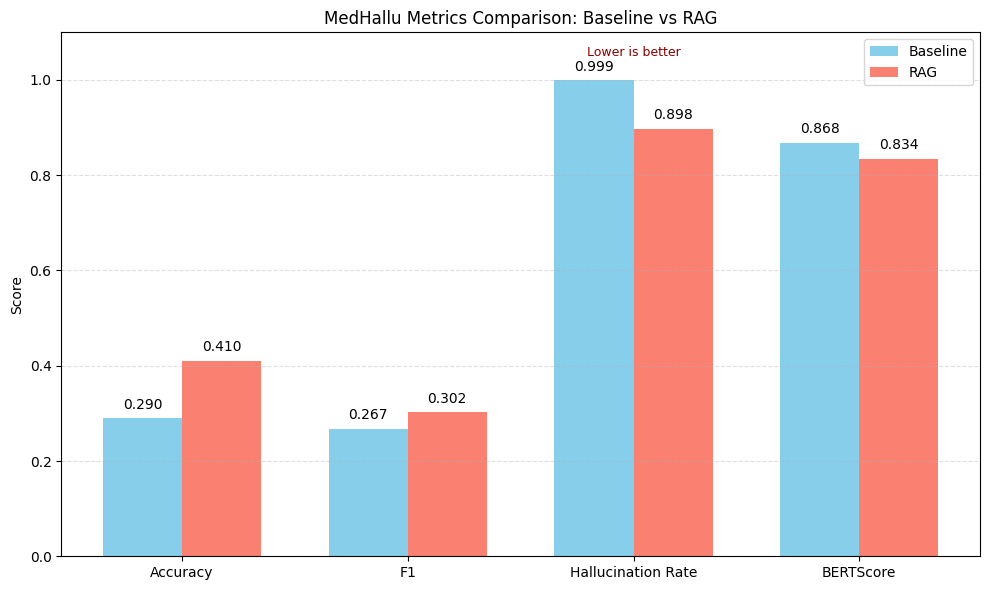

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# MedHallu metrics
metrics = {
    'Baseline Accuracy': 0.29,
    'RAG Accuracy': 0.41,
    'Baseline F1': 0.26747572815533976,
    'RAG F1': 0.3019379844961241,
    'Baseline Hallucination Rate': 0.9991019214703425,
    'RAG Hallucination Rate': 0.8978228211857217,
    'Baseline BERTScore': 0.8683149218559265,
    'RAG BERTScore': 0.8342244625091553
}

# Prepare data for plotting
metrics_to_plot = ['Accuracy', 'F1', 'Hallucination Rate', 'BERTScore']
baseline_values = [metrics[f'Baseline {m}'] for m in metrics_to_plot]
rag_values = [metrics[f'RAG {m}'] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))  # the label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline', color='skyblue')
bars2 = ax.bar(x + width/2, rag_values, width, label='RAG', color='salmon')

# Add value labels on top of each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f'{height:.3f}',
            ha='center',
            fontsize=10
        )

# Customizing the plot
ax.set_ylabel('Score')
ax.set_title('MedHallu Metrics Comparison: Baseline vs RAG')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)  # leave space for labels
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Highlight that lower is better for hallucination
for i, metric in enumerate(metrics_to_plot):
    if metric == "Hallucination Rate":
        ax.text(
            x[i],
            1.05,
            'Lower is better',
            ha='center',
            color='darkred',
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [41]:
df_medhallu_results.to_csv(
    "medhallu_200_mistral_results.csv",
    index=False
)

In [27]:
df_pubmedqa_results.to_csv(
    "pubmedqa_50_mistrall_results.csv",
    index=False
)
